### 하이퍼파라미터

- 학습 전 미리 정해주어야 하는 변수 또는 파라미터들이 존재
- alpha는 손실 함수의 정규화 항에 곱해지는 상수를 뜻하며 λ 로 표기
- iter는 경사 하강을 최대 몇 번할지 정하는 값
- 두 값은 모델이 아닌 사람이 직접 정해야 함
- 이 값에 따라 모델 성능에 차이가 있기에 중요하게 선택함

### Grid Search

- 하이퍼 파라미터에 넣어보고 싶은 후보 값을 몇개씩 정한 후, 모든 후보 값의 조합으로 모델 학습 시킨 후 성능이 가장 좋은 조합을 고름

In [3]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from math import sqrt

import numpy as np
import pandas as pd

# 경고 메시지 출력 억제 코드
import warnings
warnings.simplefilter(action='ignore')


### 데이터 불러오기

In [6]:

admission_df = pd.read_csv('admission_data.csv')

X = admission_df.drop('Chance of Admit ',axis=1)

polynomial_transformer = PolynomialFeatures(2) #2차식 변형기 정의
polynomial_features = polynomial_transformer.fit_transform(X.values)

features = polynomial_transformer.get_feature_names_out(X.columns)

X= pd.DataFrame(polynomial_features, columns = features)
y = admission_df[['Chance of Admit ']]

### 하이퍼 파라미터의 후보값들 설정

In [7]:
hyper_parameter= {
    'alpha' : [0.01, 0.1, 1, 10],
    'max_iter' : [100, 500, 1000, 1500, 2000]
}

In [8]:
lasso_model = Lasso()

In [9]:
hyper_parameter_tuner =GridSearchCV(lasso_model, hyper_parameter, cv = 5)
hyper_parameter_tuner.fit(X,y)

,estimator,Lasso()
,param_grid,"{'alpha': [0.01, 0.1, ...], 'max_iter': [100, 500, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,1


#### 결과해석

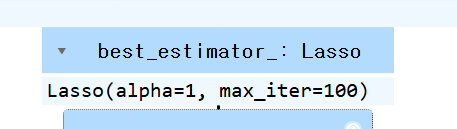
- 사진에서 alpha = 1, max_iter = 100 일때 성능이 가장 좋음 
- .best_parmas_ 명령어로 확인 가능